# Investigating the behaviour of a mass-spring system with external influence (2nd-Order nonhomogenous ODE)

**Methods:** Analytical solution of a driven oscillator (resonant vs non-resonant), NumPy, Matplotlib

### Overview
This notebook investigates the behavior of a system modeled by a 2nd-order differential equation under various external angular frequencies.

---


### Forced Oscillation in a Mass-Spring System

$$
\frac{d^2X}{dt^2}+\omega^2_pX=F_p\sin{\omega t}
$$

This notebook investigates the behavior of an undamped mass-spring system under different external forcing frequencies. The system is modeled by the second-order linear non-homogeneous ODE shown above, where the external force is represented by $g(t) = F_0\sin\omega t$.

Six different configurations are examined by varying the external angular frequency while keeping the other system parameters fixed. The behavior of each system is analyzed over the first 50 seconds of motion using (a) a time-series plot of displacement ($t$ vs $X$) and (b) a phase diagram ($X'$ vs $X$). The system starts with zero initial displacement (Dirichlet condition) and zero initial velocity (Neumann condition), and damping is not considered.

The resulting time-series and phase diagrams are then used to compare the behavior of the system under different relationships between the external angular frequency $\omega$ and the natural angular frequency $\omega_p$.

| Set-up | Mass, <br/> $m$ \[kg\] | Spring constant, <br/> $k$ \[kg/s $^2$\] | Natural angular frequency<br/> $\omega_p = \sqrt{k/m}$ \[1/s\] | External angular frequency,<br/> $\omega$ \[1/s\] | External amplitude,<br/> $F_0$ \[m/s $^2$\] |
|---|---|---|---|---|---|
|(1) | 1.0 | $\pi^2$ | $\pi$ | $0.25\pi$ | 80 |
|(2) | 1.0 | $\pi^2$ | $\pi$ | $0.5\pi$ | 80 |
|(3) | 1.0 | $\pi^2$ | $\pi$ | $2\pi$ | 80 |
|(4) | 1.0 | $\pi^2$ | $\pi$ | $4\pi$ | 80 |
|(5) | 1.0 | $\pi^2$ | $\pi$ | $1.1\pi$ | 80 |
|(6) | 1.0 | $\pi^2$ | $\pi$ | $\pi$ | 80 |

The exact solution of the above system depends on the relationship of $\omega$ and $\omega_p$.

$\omega\neq\omega_p$:

$X = \frac{F_p}{\omega^2_p-\omega^2}(-\frac{\omega}{\omega_p}\sin{\omega_pt}+\sin{\omega t})$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $X'=\frac{F_p\omega}{\omega^2_p-\omega^2}(-\cos{\omega_pt}+\cos{\omega t})$

$\omega = \omega_p$:

$X=\frac{F_p}{2\omega^2_p}(\sin{\omega_pt}-t\omega_p\cos{\omega_pt})$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $X'=\frac{F_p}{2}(t\sin{\omega_pt})$

---

#### Importing necessary modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Define shared parameters

In [2]:
dt = 0.01
t = np.arange(0,50.0+dt,dt)
m = 1.0
k = np.pi*np.pi
Fo = 80
Fp = Fo/m
wp = np.sqrt(k/m)
w = 0.25*np.pi

#### Define the functions that represent the exact solutions under various conditions

In [3]:
def w_neq_wp(t,Fp,wp,w): #The condition when w not equal to wp
  X = ((Fp)/(wp*wp-w*w))*(-(w/wp)*np.sin(wp*t) + np.sin(w*t))
  V = ((Fp*w)/(wp*wp-w*w))*(-np.cos(wp*t) + np.cos(w*t))
  label = "w ≠ wp"
  return X,V,label

def w_eq_wp(t,Fp,wp,w): #The condition when w is equal to wp
  X = (Fp/(2*(wp*wp)))*(np.sin(wp*t)-t*wp*np.cos(wp*t))
  V = (Fp/2)*(t*np.sin(wp*t))
  label = "w = wp"
  return X,V,label

def solve(t,Fp,wp,w):
  if w==wp:
    X,V,label = w_eq_wp(t,Fp,wp,w)
  else:
    X,V,label = w_neq_wp(t,Fp,wp,w)
  return X,V,label

#### The function above may be used to solve each case.

The program below also includes simple plotting for case 1.

In [4]:
X,V,label = solve(t,Fp,wp,w)

Visualizing the time-series is conducted below.

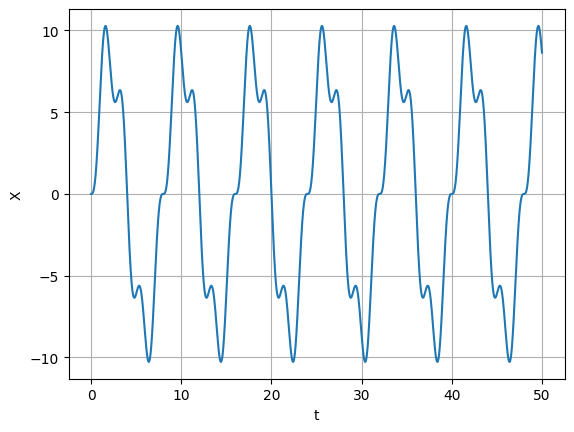

In [5]:
plt.plot(t,X)
plt.xlabel('t')
plt.ylabel('X')
plt.grid(True)

As we see from the graph there is the summation of 2 basic trigonometric functions supported by the given equation of $X = \frac{F_p}{\omega^2_p-\omega^2}(-\frac{\omega}{\omega_p}\sin{\omega_pt}+\sin{\omega t})$ which the result is a superposition of two sine functions: ${\omega_p}$ (natural frequency of the spring-mass system) and ${\omega}$ (driving frequency)

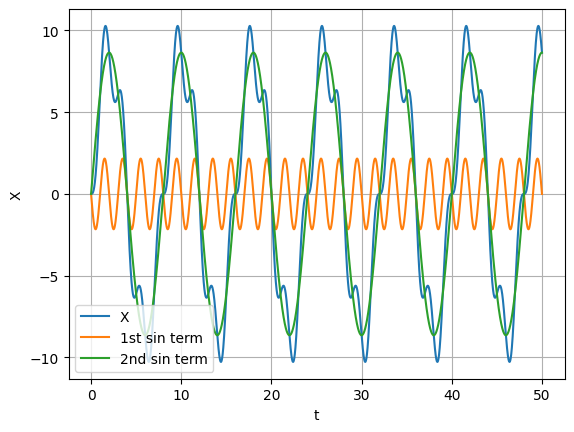

In [6]:
X1 = ((Fp)/(wp*wp-w*w))*(-(w/wp)*np.sin(wp*t))
X2 = ((Fp)/(wp*wp-w*w))*(np.sin(w*t))
plt.plot(t,X,label = "X")
plt.plot(t,X1,label = "1st sin term")
plt.plot(t,X2,label = "2nd sin term")
plt.xlabel('t')
plt.ylabel('X')
plt.legend()
plt.grid(True)

The graph above clarifies that in the case of $\omega \neq \omega_p$ the graph consists of two sine functions, which causes constructive and destructive interference.

Visualizing the phase diagram is conducted below.

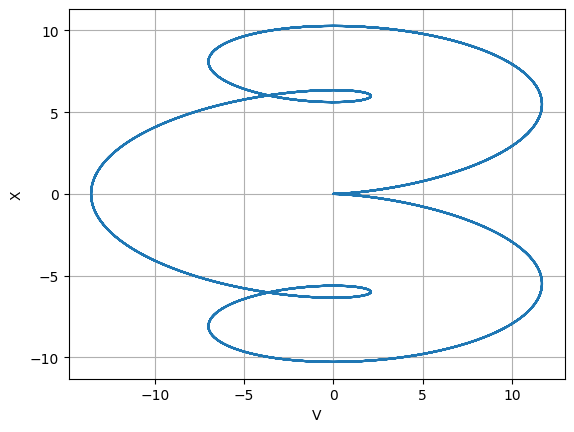

In [7]:
plt.plot(V,X)
plt.xlabel('V')
plt.ylabel('X')
plt.grid(True)

From file `02_second_order_linear_homogeneous.ipynb` , we know that a mass-spring system without a damper and no external force would exhibit an elliptical shape. The looped structure above indicates that the external force ($F_p\sin{\omega t}$) continuously inputs energy into the system, sustaining oscillations.

The external force acting on the system causes the ellipse to take on other shapes, but it still returns to its original loop since the force is also applied as a trigonometric function.

Side-by-side figure

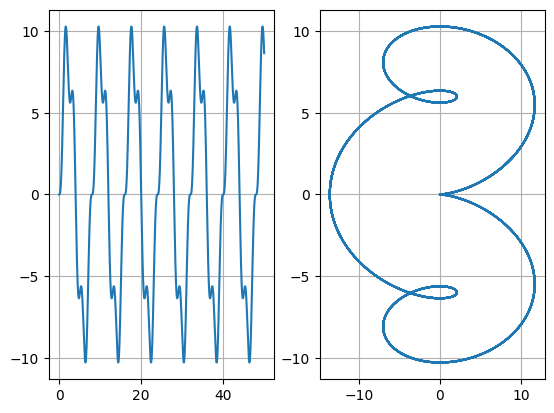

In [8]:
fig, ax = plt.subplots(1,2) # 1 row, 2 columns
ax[0].plot(t,X) # plot on 1st subplot
ax[0].grid(True)
ax[1].plot(V,X) # plot on 2nd subplot
ax[1].grid(True)

#### A more concise method to visualize all cases.

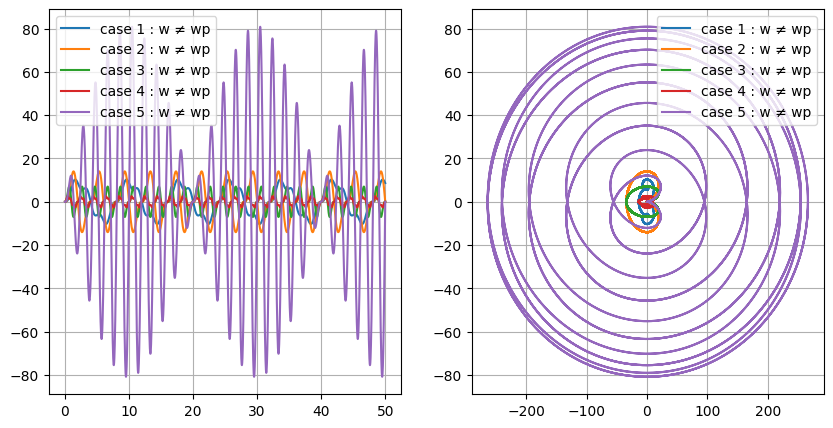

In [9]:
cases = [
         {'case':'case 1','Fp':80.0,'wp':np.pi,'w':0.25*np.pi},
         {'case':'case 2','Fp':80.0,'wp':np.pi,'w':0.5*np.pi},
         {'case':'case 3','Fp':80.0,'wp':np.pi,'w':2*np.pi},
         {'case':'case 4','Fp':80.0,'wp':np.pi,'w':4*np.pi},
         {'case':'case 5','Fp':80.0,'wp':np.pi,'w':1.1*np.pi},
         ]

fig,axs = plt.subplots(1,2,figsize=(10,5))
for ic in cases:
  X,V,label = solve(t,ic['Fp'],ic['wp'],ic['w'])
  axs[0].plot(t,X,label= ic['case']+ " : " + label)
  axs[1].plot(V,X,label= ic['case']+ " : " + label)
  axs[0].legend()
  axs[1].legend()
  axs[0].grid(True)
  axs[1].grid(True)

The above graph illustrate relation ship between $t$ and $X$, and $V$ and $X$, respectively. When $\omega_p$ and $\omega$ are close but not equal, their superposition causes constructive and destructive interference. This results in the characteristic beat pattern visible in the first graph (with high and low amplitude cycles repeating periodically).

Each case result in different trend because of the constructive and destructive interference of the 2 sine functions varies.

Moreover, the loop of relation between $V$ and $X$ is closed loop, which mean the $t$ and $X$ graph is oscillating with the same intensity and frequency infinitely.

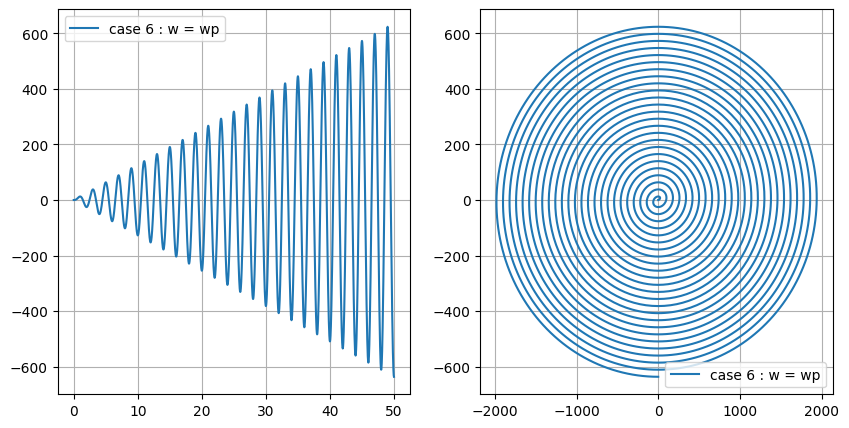

In [10]:
special_cases = [{'case':'case 6','Fp':80.0,'wp':np.pi,'w':np.pi}]

fig,axs = plt.subplots(1,2,figsize=(10,5))
for sc in special_cases:
  X,V,label = solve(t,sc['Fp'],sc['wp'],sc['w'])
  axs[0].plot(t,X,label= sc['case']+ " : " + label)
  axs[1].plot(V,X,label= sc['case']+ " : " + label)
  axs[0].legend()
  axs[1].legend()
  axs[0].grid(True)
  axs[1].grid(True)

The above graph for case 6 is added to better illustrate the situation where $\omega_p = \omega$, which is using `w_eq_wp` function. As we can see, when $\omega_p$ and $\omega$ are exactly the same, the wave resonates, and the amplitude keeps increasing over time. For the $V$ and $X$ relationship graph, it also expands outward continuously, showing that the motion becomes stronger over time.

In fact, we can already observe in case 5, where $\omega_p$ and $\omega$ are very close to each other, that resonance causes the oscillation to have very high intensity.

This effect might lead to serious damage to a structure because, without damping, the amplitude of the resonance continues to grow over time.
